The data are from HS


In [13]:

# 0️⃣ Setup
import os
import sys

print(os.getcwd())
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings("ignore")

# Add parent directory to path to import regression_scripts
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Reload module to pick up new functions
import importlib
if 'regression_scripts.regression_utils' in sys.modules:
    importlib.reload(sys.modules['regression_scripts.regression_utils'])

from regression_scripts.regression_utils import*


# -----------------------------
# 1️⃣ Load data
# -----------------------------
file_path = "../data/sensor_data.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"CSV file not found at {file_path}")
data = pd.read_csv(file_path, sep=",")
print("✅ Data loaded successfully!\n")
print(data.head())
print("\nData info:")
print(data.info())
print("\nMissing values per column:")
print(data.isna().sum())



C:\Users\mm66a\shared\ML\supervised-learning\notebooks
✅ Data loaded successfully!

   Temperature  Vibration     State
0    27.490802   3.490809   Warning
1    39.014286   2.680482  Critical
2    34.639879   1.547638   Warning
3    31.973170   4.068975  Critical
4    23.120373   3.423656   Warning

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Vibration    500 non-null    float64
 2   State        500 non-null    object 
dtypes: float64(2), object(1)
memory usage: 11.8+ KB
None

Missing values per column:
Temperature    0
Vibration      0
State          0
dtype: int64


## 2. Explore Data
#### we can see the critical state is dominant in our data 

Description
       Temperature   Vibration
count   500.000000  500.000000
mean     29.971234    2.409757
std       5.973768    1.427467
min      20.101232    0.023160
25%      24.825594    1.145496
50%      30.263275    2.359108
75%      35.122498    3.631684
max      39.859296    4.998588


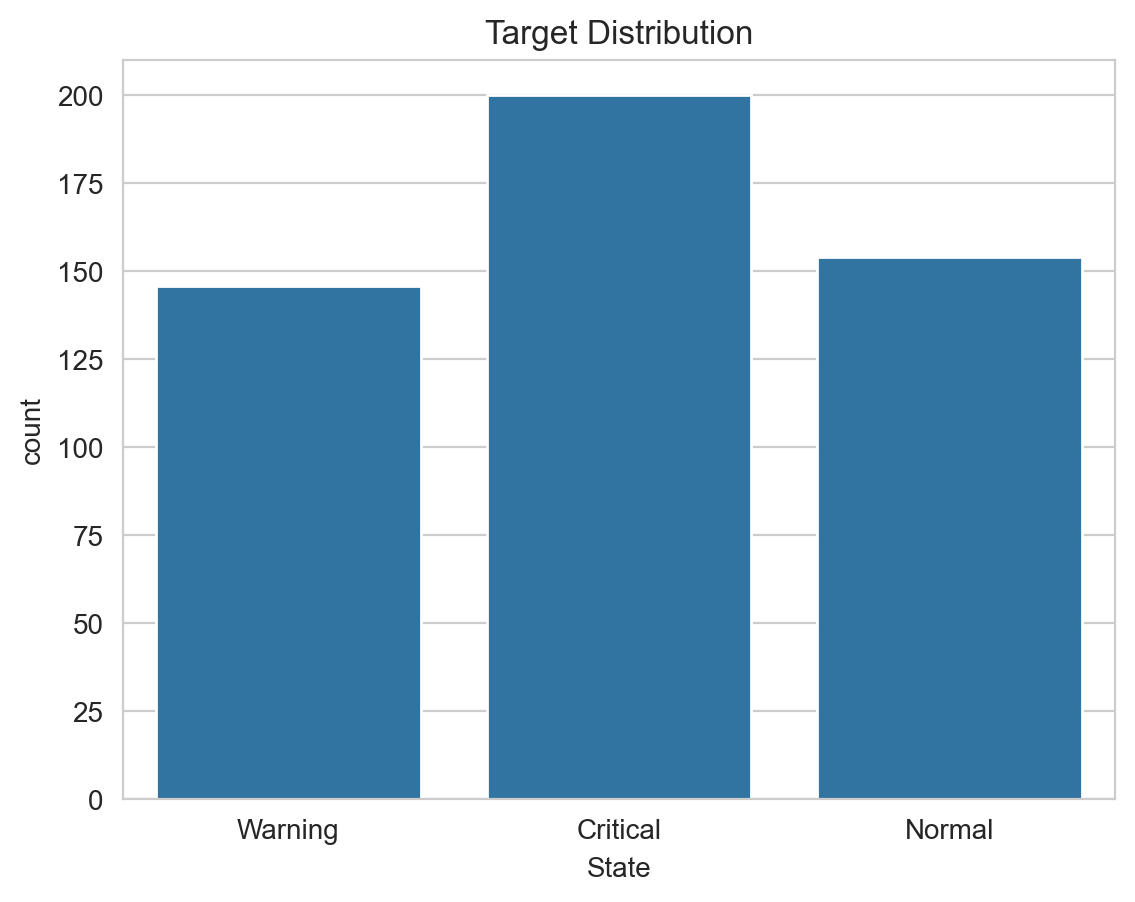

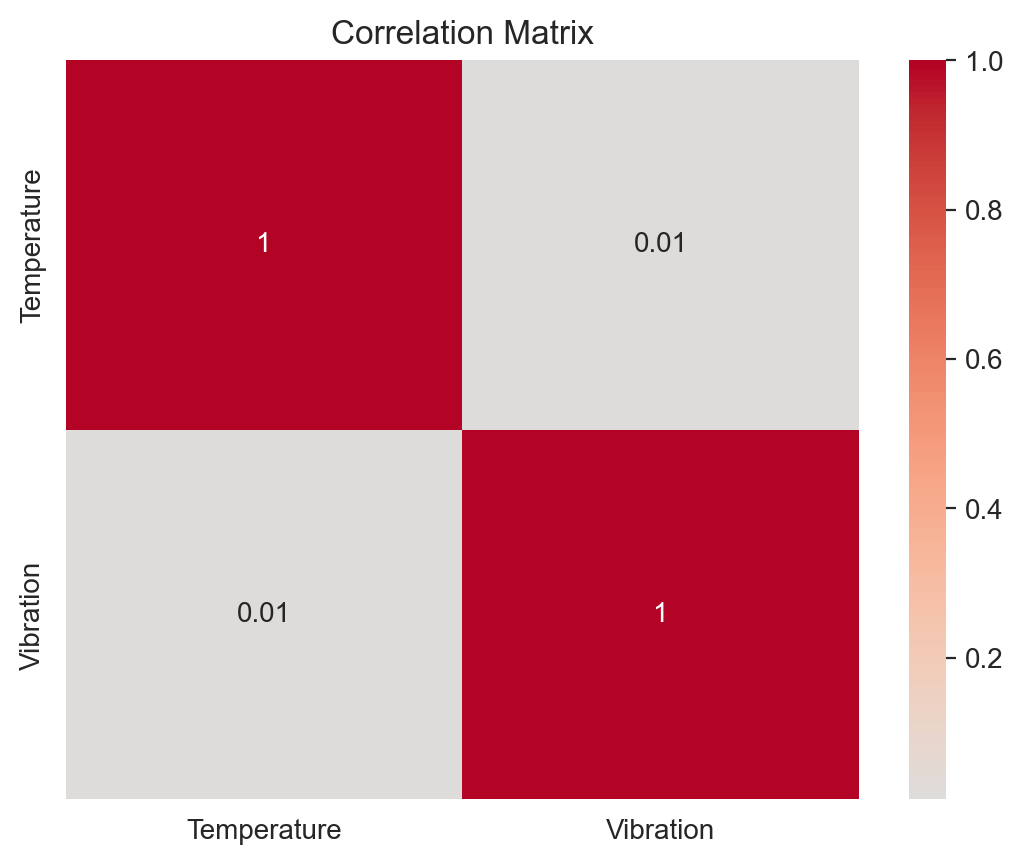

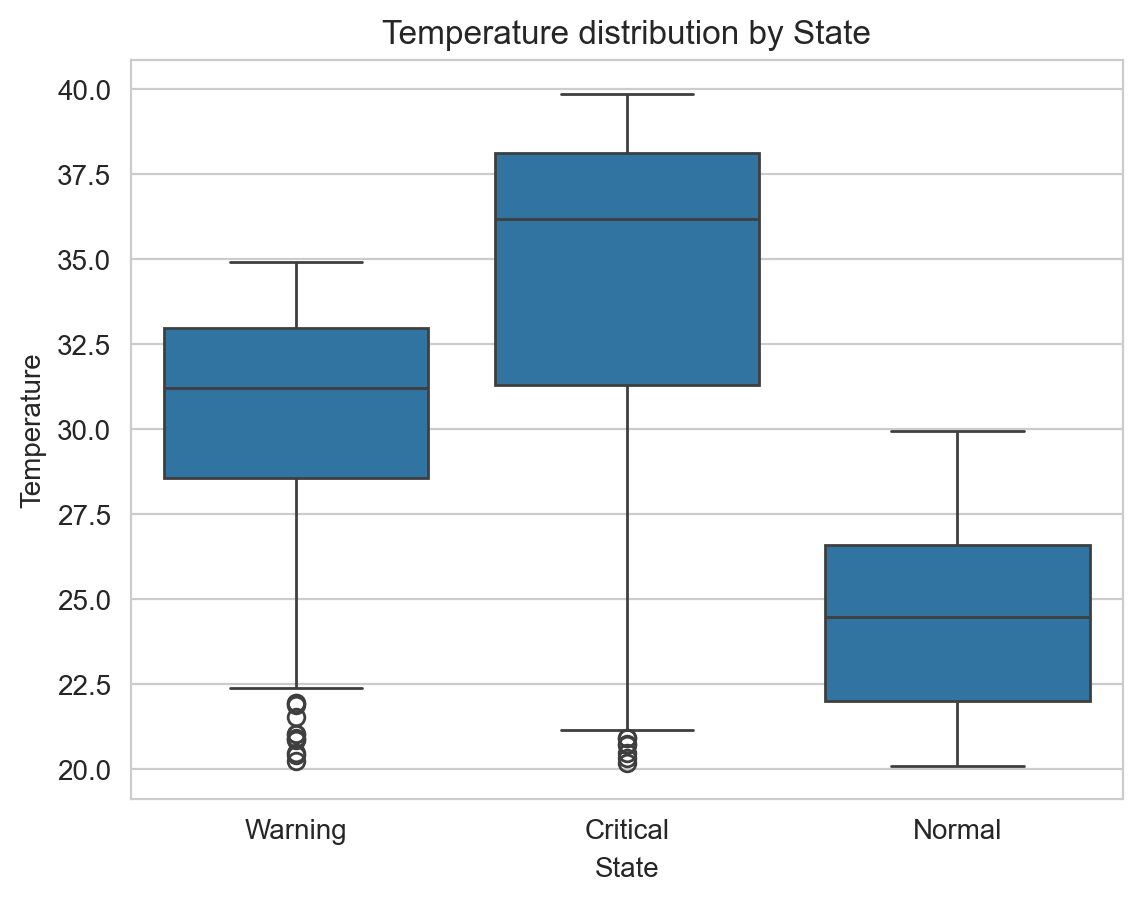

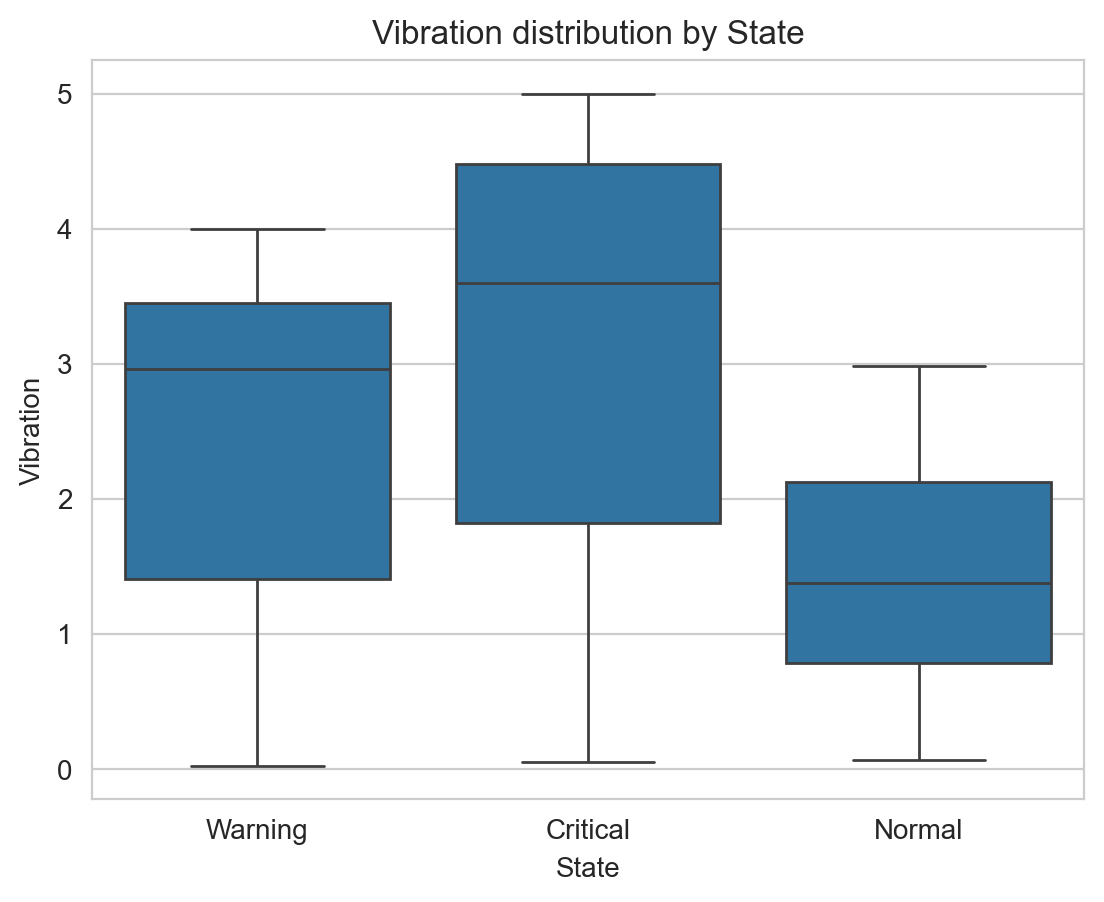

In [14]:
explore_data(data,"State")

# 3. Process Data 
## Preprocess dataset for DecisionTreeClassifier with a categorical target.
### the satae has 3 categorical values: critical, normal and warn

In [15]:
X,y=data_process(data,"State") 

# 4. Split Data
### 70% Data set , 15% Validation set and 15% Test set

In [16]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, 
    train_size=0.7, 
    val_size=0.15, 
    test_size=0.15
)


📊 Class distribution check:
Original:  [0.4   0.308 0.292]
Train:     [0.4        0.30857143 0.29142857]
Val:       [0.4        0.30666667 0.29333333]
Test:      [0.4        0.30666667 0.29333333]


# 5. Train Model


In [18]:
model=train_tree_classifier(X_train,y_train)

# 6. Evaluation of model
### metrics: accuray


In [20]:
#The model accuracy
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2f}")

print(X_train.columns)

Accuracy: 0.89
Index(['Temperature', 'Vibration'], dtype='object')


####  -> we can see the model has 89% accuracy


#### Overview of the model features:

In [21]:
print(X.columns)
print(model.feature_names_in_)


Index(['Temperature', 'Vibration'], dtype='object')
['Temperature' 'Vibration']


# 7. Decision Tree Classifier Performance on Train, Validation, and Test Sets


In [23]:
evaluate_tree_classifier_model(model, X_train, y_train, "Train")
evaluate_tree_classifier_model(model, X_val, y_val, "Validation")
evaluate_tree_classifier_model(model, X_test, y_test, "Test")



Train Evaluation
------------------------------
Accuracy: 0.9228571428571428

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       140
      Normal       0.80      0.99      0.89       108
     Warning       0.99      0.75      0.85       102

    accuracy                           0.92       350
   macro avg       0.93      0.91      0.91       350
weighted avg       0.94      0.92      0.92       350


Validation Evaluation
------------------------------
Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00        30
      Normal       0.79      1.00      0.88        23
     Warning       1.00      0.73      0.84        22

    accuracy                           0.92        75
   macro avg       0.93      0.91      0.91        75
weighted avg       0.94      0.92      0.92        75


Test Evaluation
--------------------------

array(['Warning', 'Normal', 'Critical', 'Warning', 'Normal', 'Critical',
       'Normal', 'Critical', 'Warning', 'Critical', 'Critical',
       'Critical', 'Warning', 'Critical', 'Critical', 'Normal', 'Normal',
       'Normal', 'Normal', 'Critical', 'Normal', 'Warning', 'Warning',
       'Normal', 'Critical', 'Normal', 'Normal', 'Critical', 'Critical',
       'Normal', 'Normal', 'Normal', 'Critical', 'Normal', 'Warning',
       'Normal', 'Normal', 'Critical', 'Normal', 'Critical', 'Critical',
       'Critical', 'Warning', 'Critical', 'Normal', 'Critical', 'Normal',
       'Normal', 'Normal', 'Normal', 'Critical', 'Warning', 'Normal',
       'Warning', 'Normal', 'Critical', 'Critical', 'Normal', 'Normal',
       'Critical', 'Critical', 'Critical', 'Warning', 'Critical',
       'Normal', 'Critical', 'Critical', 'Critical', 'Normal', 'Critical',
       'Warning', 'Normal', 'Warning', 'Normal', 'Warning'], dtype=object)

# 7.1 Confusion Matrix
My model is doing great on Critical and Normal — 100% correct on both.
It struggles a bit with Warning: 8 out of 22 got labeled as Normal.
Overall accuracy is 89%, and most importantly, it never misses a Critical failure. That’s what really matters.

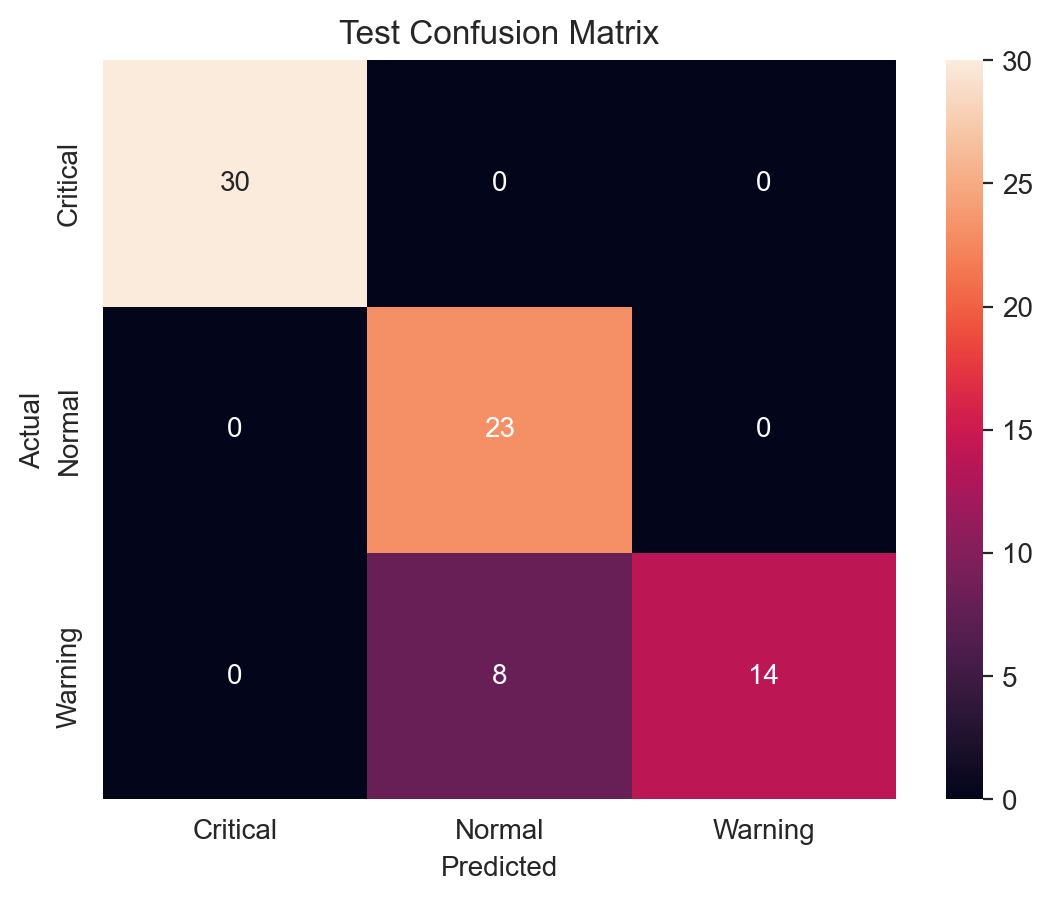

In [25]:
plot_confusion_matrix(model, X_test, y_test, "Test Confusion Matrix")

 # 7.2  Decision Tree Thresholds:
 - If **Temperature > 34.925** → **Critical** (94 samples, pure)
- If **Temperature ≤ 34.925**:
  - If **Vibration > 4.007** → **Critical** (46 samples, pure)
  - If **Vibration ≤ 4.007**:
    - If **Temperature ≤ 29.882** → **Normal** (mostly Normal, some Warning)
    - If **Temperature > 29.882** → **Warning** (almost pure Warning)


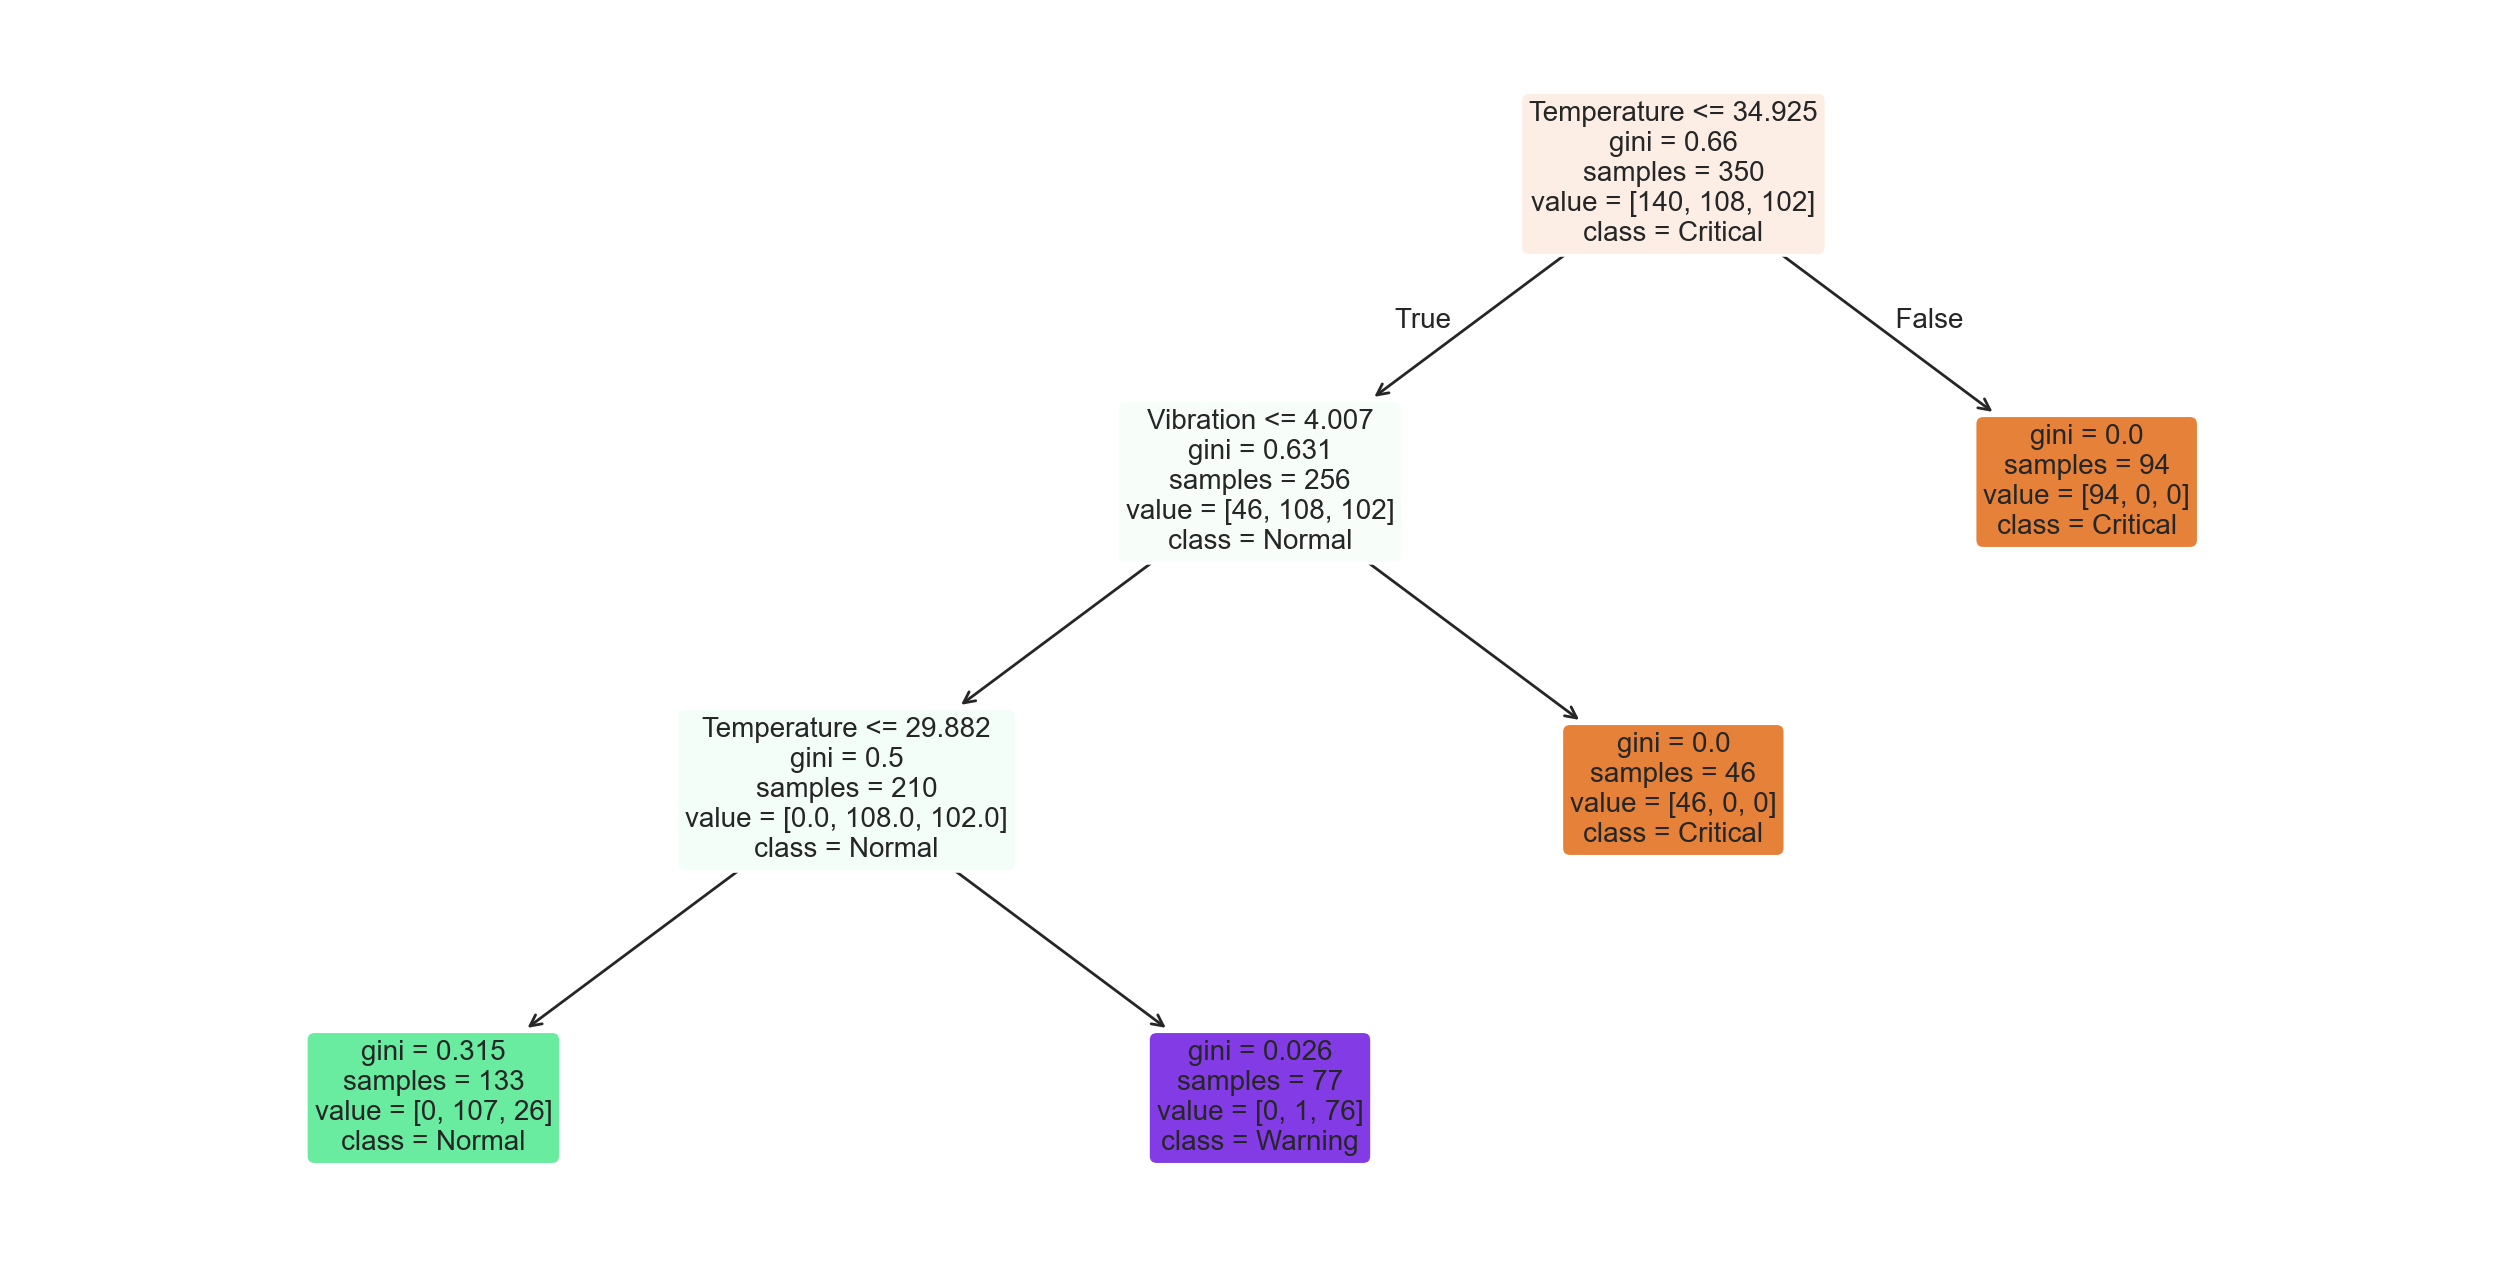

In [26]:
visualize_decision_tree(model, X_train)

# 8. Plot predictions vs Actual

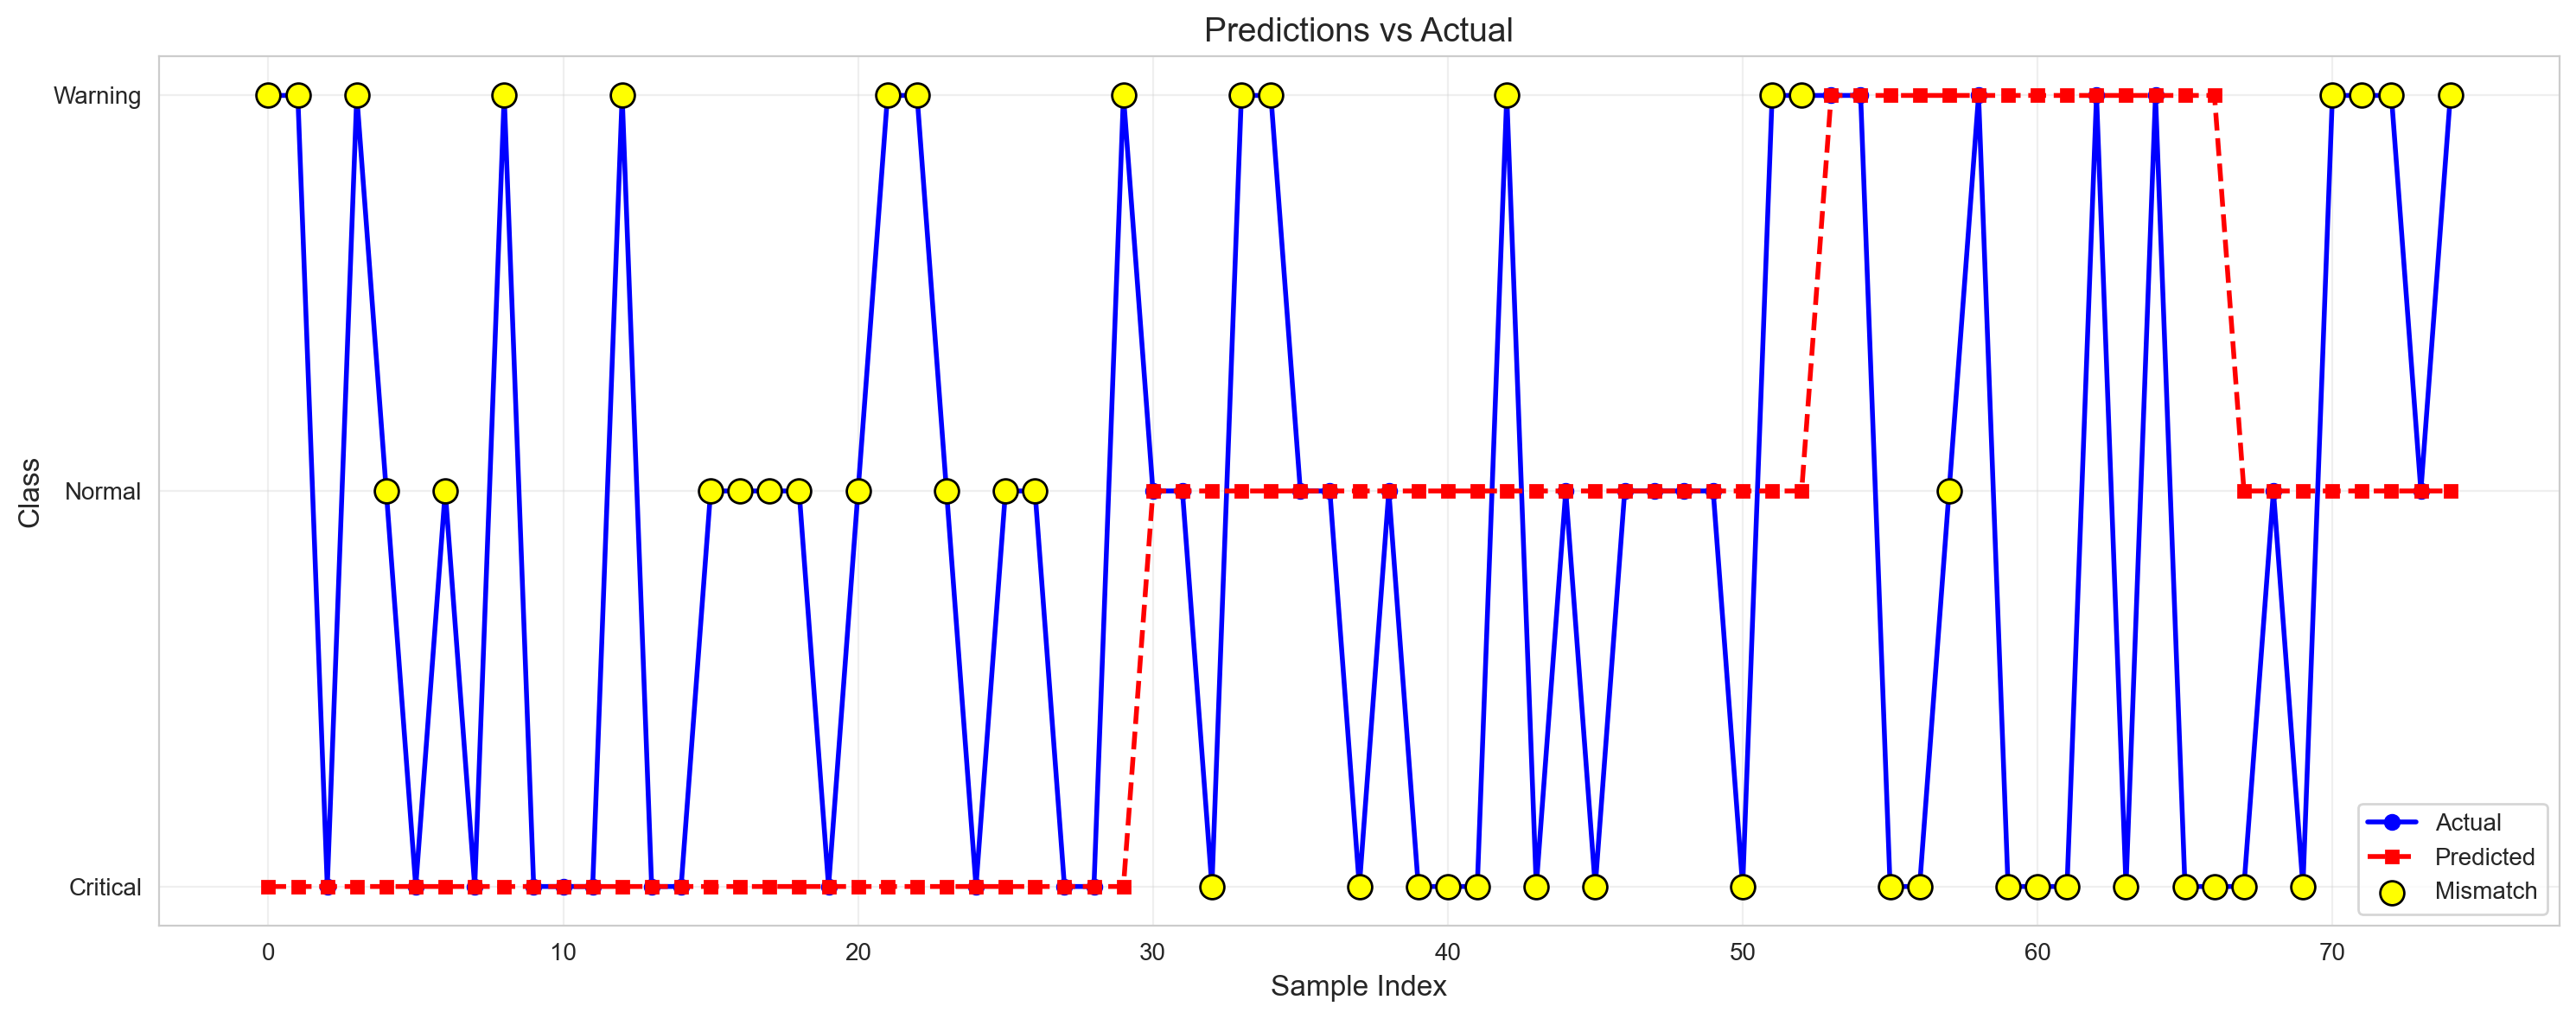

✅ Correct: 29/75 (38.7%)
❌ Errors:  46/75 (61.3%)


In [33]:

Y_pred = model.predict(X_test)  
plot_predictions_vs_actual(y_test, y_pred, title="Predictions vs Actual")

Critical: Temp > 34.925 OR (Temp ≤ 34.925 & Vibration > 4.007) → 100% correct

Normal: Temp ≤ 34.925, Vibration ≤ 4.007, Temp ≤ 29.882 → 100% correct

Warning: Temp ≤ 34.925, Vibration ≤ 4.007, Temp > 29.882 → 64% correct (8/22 misclassified as Normal)

Overall: 89% accuracy. Perfect on safety-critical cases. Minor Warning/Normal confusion only. Ready for use.